In [1]:
import cafe

cafe.logger.setLevel("DEBUG")

cafe.settings.backend = "conda"
cafe.settings.save_h5ad = True

INFO                                                                                                                                                                                                    
            _____     _ _ ______    _       ______            _                                                                                                                                         
           / ____|   | | |  ____|  | |     |  ____|          | |                                                                                                                                        
          | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __                                                                                                                     
          | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__|                                                                                                                

In [2]:
fadata = cafe.data.read_h5ad("../../tests/data/pancrease_scvelo_500_fadata.h5ad")
fadata.id = "pancreas_500"
fadata.add_prior_information(start_cell="cell_000")

fadata

DEBUG    |- Create a FateAnnData object from an existing AnnData object.                                                                                                                                
DEBUG    |- recognizing prior information...                                                                                                                                                            
DEBUG    |--- recognize 'clusters' in '.obs' columns as 'cluster' key                                                                                                                                   
DEBUG    |--- recognize 'X_umap' in '.obsm' keys as 'basis' key                                                                                                                                         
DEBUG    |- unserialize trajectory dict: 'ref'                                                                                                                                                      

AnnData object with n_obs × n_vars = 500 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score'
    uns: 'cfe', 'id'
    obsm: 'X_pca', 'X_umap'
    layers: 'count', 'expression', 'spliced', 'unspliced'

In [3]:
parameters = {
    "repreprocess": True,
}
method = cafe.method.FateMethod(method_name="scvelo")
method.infer_trajectory(fadata, parameters)

DEBUG    |- load conda backend                                                                                                                                                                          
DEBUG    |--- Conda environment 'cfe' is available: Python 3.10.15                                                                                                                                      
DEBUG    |- Loaded function 'scvelo': <function scvelo at 0x7f7eaa6abc70>                                                                                                                               
INFO     |- method backend loaded: CondaBackend: scvelo in conda env 'cfe'                                                                                                                              
DEBUG    |- set new log file: .cfe/pancreas_500/log/20251107_144507__scvelo-conda__lSvTcmgIBf.log                                                                                                   

DEBUG    |- extract 'X_umap' from prior infomation as parameter 'basis'                                                                                                                                 
DEBUG    |- calculate new trajectory embedding for model_name:20251107_144507__scvelo-conda__lSvTcmgIBf, basis:X_umap.                                                                                  
DEBUG    |- add waypoints                                                                                                                                                                               
DEBUG    |- FateAnnData add_waypoints                                                                                                                                                                   
DEBUG    |- add waypoints shape is (210, 500) for '20251107_144507__scvelo-conda__lSvTcmgIBf', finished!                                                                                            

<Axes: title={'center': 'scvelo-conda(clusters)'}, xlabel='X_umap1', ylabel='X_umap2'>

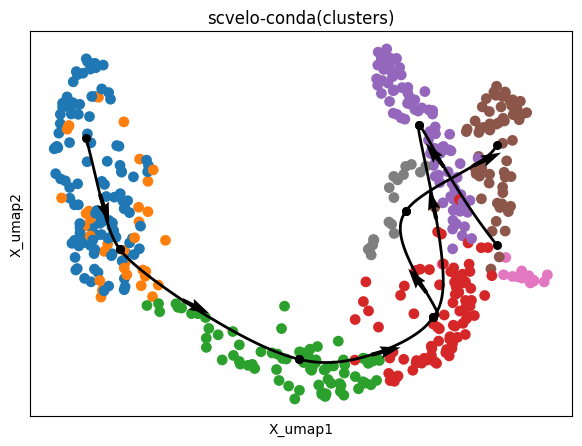

In [4]:
# fix for isolated milestones and cells.
cafe.plot.plot_trajectory(fadata, color="clusters")

In [5]:
# TODO Velocity Wrapper UMAP优化

In [15]:
import scanpy as sc
from cafe.method.function.cf_scvelo  import extract_trajectory_dict

# 既可以去读取中间h5ad文件
adata = sc.read(".cfe/pancreas_500/h5ad/20251107_144507__scvelo-conda__lSvTcmgIBf.h5ad") 
# 又可以从h5ad文件添加轨迹
fadata.add_model_name("scvelo-conda-rewrite")
trajectory_dict = extract_trajectory_dict(adata)
fadata.add_trajectory_by_type(trajectory_dict)
fadata.get_all_model_name()

DEBUG    |- Add trajectory by wrapper type: velocity                                                                                                                                                    
DEBUG    |- Create a FateAnnData object from an existing AnnData object.                                                                                                                                
DEBUG    |- recognizing prior information...                                                                                                                                                            
DEBUG    |--- recognize 'clusters' in '.obs' columns as 'cluster' key                                                                                                                                   
DEBUG    |--- recognize 'X_umap' in '.obsm' keys as 'basis' key                                                                                                                                     

['ref', 'scvelo-conda', 'scvelo-conda-rewrite']